Para Verificar Performance da GPU Usar o Comando:

watch -n 1 amd-smi

## Modo do Script:

TRAIN: o modelo será treinado e o melhor registrado será salvo.

TEST: o modelo salvo será testado com o dataset de teste

BOTH: o modelo sera treinado, salvo e testado

# Setup do Projeto

In [1]:
import torch
from config import *

# Setup Agnostic Code for GPU/CPU
if torch.cuda.is_available():
    device = 'cuda'
    print(f"CUDA está disponivel!\nDispositivo configurado para: {device}\nDevice count: {torch.cuda.device_count()}\nNome do dispositivo: {torch.cuda.get_device_name(0)}\nVersao do PyTorch: {torch.__version__}")
else:
    device = 'cpu'
    print(f"CUDA não está disponível.\nDispositivo configurado para: {device}\nVersao do PyTorch: {torch.__version__}")

CUDA está disponivel!
Dispositivo configurado para: cuda
Device count: 1
Nome do dispositivo: AMD Radeon RX 7800 XT
Versao do PyTorch: 2.8.0+rocm7.2.0.gitbf943426


In [2]:
# Bibliotecas e imports
import custom_cityscapes as ccs
import custom_transforms as ctr
import custom_metrics as cmt
import models.FastSCNN as fscnn
import models.QFastSCNN as qfscnn
import train.train_model as tr
import train.train_quant_model as qtr
import eval_model as ev
from utils import *

import math
from torchvision import datasets
from torch.utils.data import DataLoader
from torchinfo import summary
from torch import optim
import torch.nn.functional as F
import onnx
from kornia import losses
from brevitas.export import export_qonnx # onnx compativel com o FINN
# Mais informacoes em https://lightning.ai/docs/torchmetrics/stable/classification/jaccard_index.html#torchmetrics.classification.MulticlassJaccardIndex
from torchmetrics.classification import MulticlassJaccardIndex # Jaccard Index eh a mesma coisa que IoU (Intersection over Union) e esse opjeto pode calcular tambem iIoU
from pathlib import Path
import json
import sys
from contextlib import redirect_stdout, redirect_stderr
import socket

/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /home

# Preparando o Dataset Cityscapes

In [3]:
ds_lables = ccs.CityscapesLables()

# Criando o colormap para as classes
cmap = ds_lables.get_cmap()

# Imprimindo informacoes relevantes
print(f"O dataset possui {len(ds_lables.id_names)} classes treinaveis:")
ds_lables.id_names

O dataset possui 5 classes treinaveis:


{0: 'road', 1: 'vehicle', 2: 'human', 3: 'other', 255: 'ignore'}

# Importar o Dataset Cityscapes

Definir Funções de Transform

In [4]:
custom_trans = ctr.Transforms(conv_size=(IM_HEIGHT, IM_WIDTH),
                              lable_conversion=ds_lables.lable_conversion)

Importar Dataset

In [5]:
train_dataset = ccs.AugmentedCityscapes(DATA_PATH,
                             split = 'train',
                             mode='fine',
                             target_type='semantic',
                             transform=custom_trans.train_transform_square,
                             target_transform=custom_trans.target_transform_square,
                             data_augmentation=custom_trans.data_augmentation,
                             post_data_augmentation=custom_trans.post_data_augmentation)
val_dataset = datasets.Cityscapes(DATA_PATH,
                           split = 'val',
                           mode='fine',
                           target_type='semantic',
                           transform=custom_trans.val_transform_square,
                           target_transform=custom_trans.target_transform_square)
test_dataset = datasets.Cityscapes(DATA_PATH,
                            split = 'test',
                            mode='fine',
                            target_type='semantic',
                            transform=custom_trans.val_transform_square)

In [6]:
# Imprimir informacoes importantes dos datasets
img, smnt = train_dataset[0]
print(f"O Dataset de treino possui {len(train_dataset)} amostras.\n"
      f"O Dataset de validação possui {len(val_dataset)} amostras.\n"
      f"O Dataset de teste possui {len(test_dataset)} amostras.\n"
      f"Cada imagem posssui tamanho {img.shape} e tipo {img.dtype}, e cada mascara possui tamanho {smnt.shape} e tipo {smnt.dtype}.\n")

#print(f"Primeira Imagem do dataset de treino:\n{img}\nPrimenra mascara do dataset de treino:\n{smnt}")

O Dataset de treino possui 2975 amostras.
O Dataset de validação possui 500 amostras.
O Dataset de teste possui 1525 amostras.
Cada imagem posssui tamanho torch.Size([3, 512, 512]) e tipo torch.float32, e cada mascara possui tamanho torch.Size([512, 512]) e tipo torch.uint8.



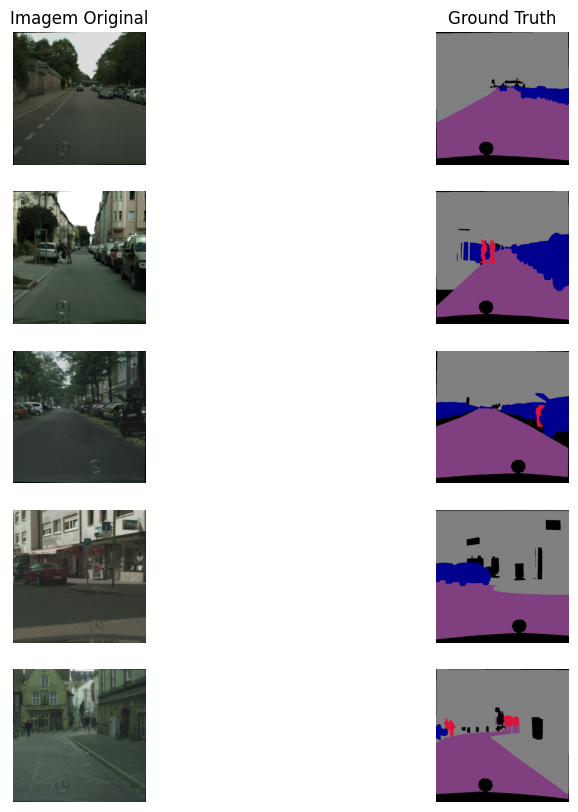

In [6]:
# Testando a funcao de exibicao
dataset_show(train_dataset, n=5, cmap=cmap)

In [6]:
# Gerar lista com pesos para as classes a partir do histograma de frequencia das classes no dataset

# Define e cria pasta para salvar pesos e histogramas
save_path = "./classes_weights"

# Metodo para calcular os pesos das classes, pode ser 'enet', 'median_freq_balancing' ou 'logarithmic'
method = 'enet'

# Define o caminho do arquivo onde os pesos das classes serao salvos, e cria a pasta caso ela nao exista
save_path = Path(save_path)
save_path.mkdir(parents=True, exist_ok=True)

if GENERATE_HISTOGRAM:

    # Criar um dataset sem data augmentation para calcular o histograma de frequencia das classes no dataset, e consequentemente os pesos das classes
    histogram_dataset = datasets.Cityscapes(DATA_PATH,
                                            split = 'train',
                                            mode='fine',
                                            target_type='semantic',
                                            transform=custom_trans.val_transform_square,
                                            target_transform=custom_trans.target_transform_square)
    
    # Criar um dataloader para o dataset de histograma, sem shuffle, para calcular o histograma de frequencia das classes no dataset
    histogram_dataloader = DataLoader(histogram_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
    
    # Chama a funcao para calcular os pesos e o histograma, e os salva na pasta definida
    class_weights = ds_lables.get_weights(histogram_dataloader, method=method, print_histogram=True, save_path=save_path, device=device)

    print(f"Pesos das classes calculados e salvos no arquivo {save_path}:\n{class_weights}")

else:
    # pega os pesos das classes calculados anteriormente
    file_path = Path(save_path) / Path(f'class_weights_{method}.json')
    with open(file_path, "r") as f:
        class_weights = torch.tensor(list(json.load(f).values())).to(device) # Carrega os pesos das classes do arquivo salvo anteriormente e converte para tensor
        print(f"Pesos das classes carregados do arquivo {file_path}:\n{class_weights}")

/tmp/ipykernel_167200/3758887690.py:35: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:36.)
  class_weights = torch.tensor(list(json.load(f).values())).to(device) # Carrega os pesos das classes do arquivo salvo anteriormente e converte para tensor


Pesos das classes carregados do arquivo classes_weights/class_weights_enet.json:
tensor([ 2.9826, 13.4736, 31.1648,  2.6854], device='cuda:0')


Criar dataloaders

In [7]:
# Criando datalaoders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)

In [8]:
# Imprimindo informacoes relevantes dos dataloaders
train_features_batch, train_labels_batch = next(iter(train_dataloader))
val_features_batch, val_labels_batch = next(iter(val_dataloader))
print(f"O pacote de imagens para treino possui tamanho: {train_features_batch.size()}, e o tamanho do pacote da mascaras para treino possui tamanho: {train_labels_batch.size()}")
print(f"O pacote de imagens para validacao possui tamanho: {val_features_batch.size()}, e o tamanho do pacote da mascaras para validacao possui tamanho: {val_labels_batch.size()}")

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=86056) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


O pacote de imagens para treino possui tamanho: torch.Size([12, 3, 512, 512]), e o tamanho do pacote da mascaras para treino possui tamanho: torch.Size([12, 512, 512])
O pacote de imagens para validacao possui tamanho: torch.Size([12, 3, 512, 512]), e o tamanho do pacote da mascaras para validacao possui tamanho: torch.Size([12, 512, 512])


## Criar Modelo 

In [10]:
# -- IMPORTANDO OS PESO DO MODELO ORIGINAL PARA O PROJETO --

if Path("./model_weights/og_params/fast_scnn_citys.pth").is_file():
    print("Os pesos originais do modelo ja foram baixados anteriormente, pulando download.")
else:
    !git clone https://github.com/Tramac/Fast-SCNN-pytorch.git # clona repositorio com modelo e pesos originais do Fast-SCNN
    !cp ./Fast-SCNN-pytorch/weights/fast_scnn_citys.pth ./model_weights/og_params/fast_scnn_citys.pth # copia os pesos originais do modelo para a pasta do projeto
    !rm -rf ./Fast-SCNN-pytorch # remove o repositorio clonado para economizar espaco

Os pesos originais do modelo ja foram baixados anteriormente, pulando download.


In [8]:
# CRIANDO O MODELO
model = fscnn.FastSCNN(num_classes=NUM_CLASSES, aux=False, strict=False)
model = load_size_compatible_state_dict(model, path="./model_weights/og_params/fast_scnn_citys.pth")
model = model.to(device)


# Evita erro de memória no torchinfo com resolução alta
model.eval()
summary(model,
        input_size=(1, 3, *IM_SIZE),
        device=device,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]) # especificando para mostrar os nomes das variaveis, o que ajuda a entender melhor a arquitetura do modelo e a quantidade de parametros treinaveis em cada camada.

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
FastSCNN (FastSCNN)                                     [1, 3, 512, 512]     [1, 4, 512, 512]     --                   True
├─LearningToDownsample (learning_to_downsample)         [1, 3, 512, 512]     [1, 64, 64, 64]      --                   True
│    └─_ConvBNReLU (conv)                               [1, 3, 512, 512]     [1, 32, 255, 255]    --                   True
│    │    └─Sequential (conv)                           [1, 3, 512, 512]     [1, 32, 255, 255]    928                  True
│    └─_DSConv (dsconv1)                                [1, 32, 255, 255]    [1, 48, 128, 128]    --                   True
│    │    └─Sequential (conv)                           [1, 32, 255, 255]    [1, 48, 128, 128]    1,984                True
│    └─_DSConv (dsconv2)                                [1, 48, 128, 128]    [1, 64, 64, 64]      --                   True
│  

In [9]:
# Definir loss, optim e metricas

# Separa em dois grupos de parametros para aplicar diferentes decaimentos de pesos (L2 regularization), conforme mencionado no artigo original do Fast-SCNN
depthwise_params = []
non_depthwise_params = []
for name, param in model.named_parameters():
    # procura por convolucoes depthwise, que possuem kernel com 1 canal de entrada. Ex: [32, 1, 3, 3] (32 kernels de dimencao 3x3, um para cada canal)
    if param.requires_grad:
        if len(param.shape) == 4 and param.shape[1] == 1:
            depthwise_params.append(param)
        else:
            non_depthwise_params.append(param)

focal_loss = losses.FocalLoss(alpha=0.25, gamma=1.0, reduction='mean', weight=class_weights, ignore_index=255).to(device) # Focal Loss com pesos para lidar melhor com o desbalanceamento de classes
focal_tvensky_loss = cmt.FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=1.33, eps=1e-8, ignore_index=255).to(device) # Perda baseada em regiao, baseado em IoU, no entando com pesos para falsos positivos e falsos negativos, alem de correcao focal.
loss_fn = lambda outputs, targets: focal_loss(outputs, targets) + focal_tvensky_loss(outputs, targets) # Combinacao das duas loss functions para aproveitar os beneficios de ambas

optim_fn = optim.AdamW([
    {'params': depthwise_params, 'weight_decay': 0.0},
    {'params': non_depthwise_params, 'weight_decay': 4e-5}
], lr=LEARNING_RATE) # Otimizador com grupos de parametros para aplicar taxas de aprendizado diferentes no encoder e decoder

IoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='none').to(device)
mIoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='macro').to(device)
metrics = {'IoU': IoU_metric, 'mIoU': mIoU_metric} # Dicionário de metricas para facilitar o monitoramento durante o treinamento e validacao

# Escolha da metrica que sera avaliada para salvar o melhor modelo, pode ser 'loss' ou o nome de alguma metrica definida no dicionario de metricas, como 'IoU' ou 'mIoU'
val_to_monitor = 'mIoU'

In [10]:
# Testar entradas e saidas do Modelo com uma imagem do dataset
test_input = train_dataset[0][0].unsqueeze(0).to(device) # Adiciona uma dimensão de batch e move para o dispositivo
test_output = model(test_input)
test_output_softmax = torch.softmax(test_output, dim=1).argmax(dim=1)
print(f"Tamanho da entrada: {test_input.shape}\n"
      f"Tamanho da saida: {test_output.shape}\n"
      f"Tamanho da saida com softmax: {test_output_softmax.shape}")
test_output_softmax

Tamanho da entrada: torch.Size([1, 3, 512, 512])
Tamanho da saida: torch.Size([1, 4, 512, 512])
Tamanho da saida com softmax: torch.Size([1, 512, 512])


tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [3, 3, 3,  ..., 3, 3, 3],
         [3, 3, 3,  ..., 3, 3, 3],
         [3, 3, 3,  ..., 3, 3, 3]]], device='cuda:0')

## Treinar Modelo E MOSTRAR RESULTADOS

Testes de Sanidade

Antes de trainar o modelo, vamos verificar a sua performance com os pesoss pré-treinados

In [10]:
# Testar Parametros
eval_model = torch.compile(model) # Compila o modelo para melhorar a performance.
sanity_check = ev.EvalModel(model=eval_model, device=device)
sanity_metrics = sanity_check.eval(val_dataloader, metrics, loss_fn)

  0%|          | 0/16 [00:00<?, ?it/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=138036) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
100%|██████████| 16/16 [00:35<00:00,  2.21s/it]

Eval Results: Loss - 1.1568 | mIoU - 0.0112 | 


In [11]:
sanity_metrics

[tensor([1.0837e-02, 3.3911e-02, 7.3200e-06, 0.0000e+00]), tensor(0.0112)]

In [12]:
# Treinar o modelo
#%env TORCH_USE_HIP_DSA=1
if SCRIPT_MODE != "TEST":
    model = torch.compile(model) # Compila o modelo para melhorar a performance.
    fit_model = tr.TrainModel(model, loss_fn, optim_fn, metrics,
                                val_to_monitor=val_to_monitor,
                                scheduler_name="OneCycleLR", # Scheduler para reduzir a taxa de aprendizado quando a metrica monitorada parar de melhorar, o que ajuda a escapar de platos e melhorar a convergencia.
                                div_factor = 10, # valido apenas para o OneCycleLR, e ignorado caso scheduler_fn seja diferente de "OneCycleLR"
                                epochs=EPOCHS,
                                device=device)
    
    fit_model(train_dataloader, val_dataloader)

Melhor valor da metrica monitorada (mIoU) registrado no modelo salvo: 0.5460

EPOCH 1/10


  0%|          | 0/93 [00:00<?, ?it/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=138036) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
100%|██████████| 93/93 [01:58<00:00,  1.28s/it] 


train_loss: 1.0411 | train_mIoU: 0.1139 | val_loss: 0.8963 | val_mIoU: 0.2267 | 

EPOCH 2/10


100%|██████████| 93/93 [01:20<00:00,  1.16it/s]


train_loss: 0.6763 | train_mIoU: 0.3744 | val_loss: 0.4319 | val_mIoU: 0.4931 | 

EPOCH 3/10


...

train_loss: 0.1469 | train_mIoU: 0.6622 | val_loss: 0.1420 | val_mIoU: 0.6663 | 

EPOCH 9/10


100%|██████████| 93/93 [01:20<00:00,  1.16it/s]


train_loss: 0.1433 | train_mIoU: 0.6657 | val_loss: 0.1404 | val_mIoU: 0.6675 | 

EPOCH 10/10


100%|██████████| 93/93 [01:18<00:00,  1.18it/s]


train_loss: 0.1429 | train_mIoU: 0.6650 | val_loss: 0.1400 | val_mIoU: 0.6693 | 

Treino do modelo foi finalizado!
O modelo com melhor mIoU foi registrado no Epoch 10.
Esse modelo foi salvo no caminho model_weights/new_params/best_model.pth


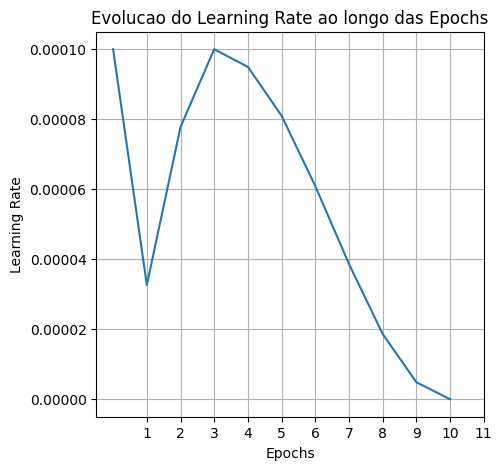

In [13]:
# Imprimir evolucao dos learning rates
if SCRIPT_MODE != "TEST":
    plot_leaning_rate_evolution(fit_model.learning_rates)

## TESTAR MODELO SALVO

Carregando modelo best_model
Carregando resultados do modelo best_model_results


<Figure size 500x500 with 0 Axes>

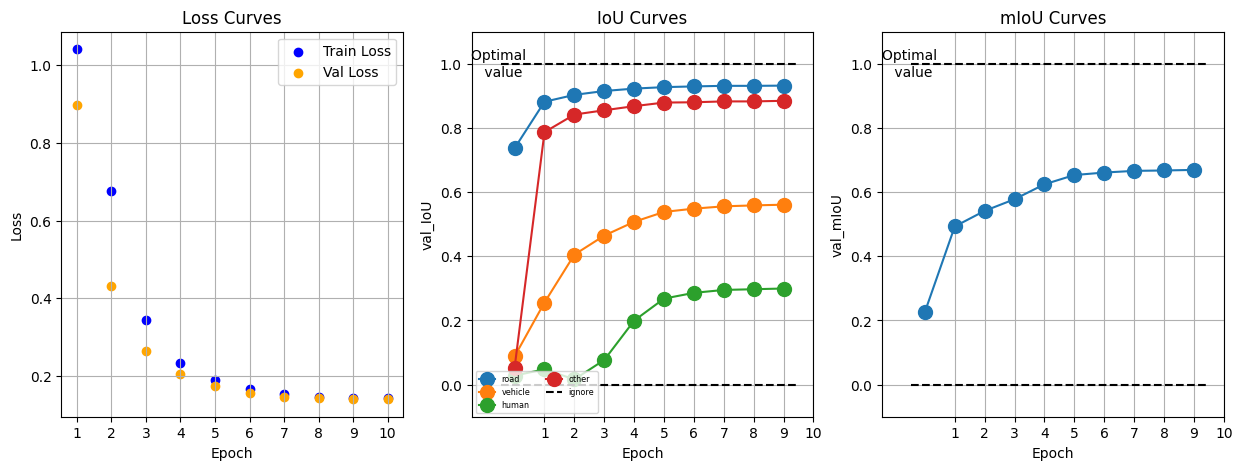

In [12]:
if SCRIPT_MODE != "TRAIN":

    # Criando novo modelo para carregar o salvo
    loaded_model = fscnn.FastSCNN(num_classes=NUM_CLASSES, aux=False).to(device)

    # Carregando apenas os parametros (state_dict()), pois isso flexibiliza o modelo e evita erros de incompatibilidade com parametros e caminhos do modelo original
    eval_fastscnn = ev.EvalModel(model = loaded_model,
                                 state_dict_path="./model_weights/new_params/best_model.pth",
                                 results_path="./model_weights/new_params/best_model_results.pt",
                                 device=device)
    
    # Imprimir os resultados
    print_results(eval_fastscnn.train_results, metrics)
    best_loaded_results = eval_fastscnn.get_best_results(IoU_lables=ds_lables.id_names)

In [13]:
best_loaded_results

{'val_loss': 0.14004092244431376,
 'val_IoU': {'road': 0.9319906830787659,
  'vehicle': 0.5608605742454529,
  'human': 0.2996031939983368,
  'other': 0.8846839666366577},
 'val_mIoU': 0.6692845821380615}

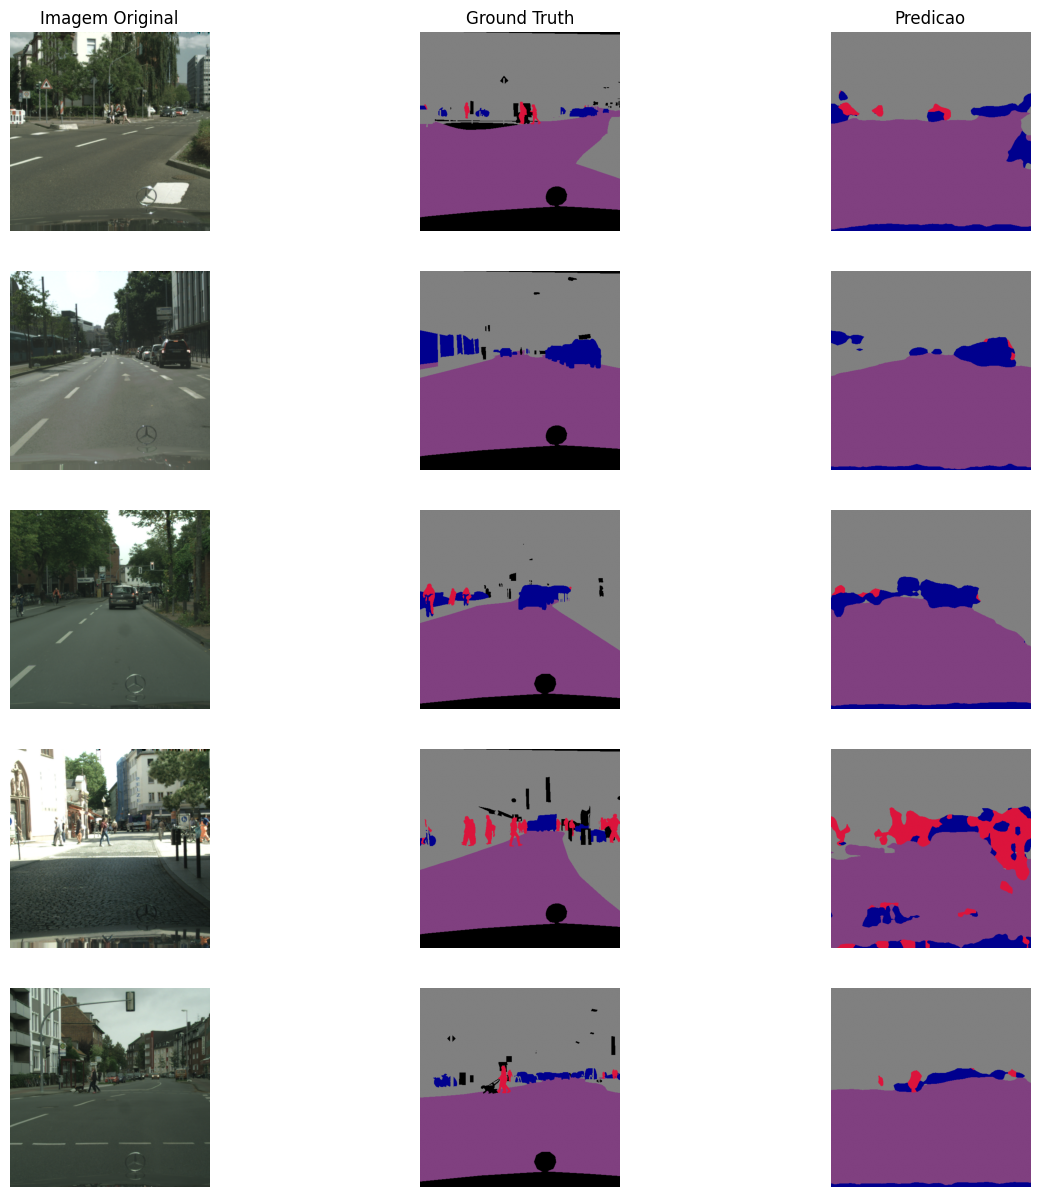

In [14]:
# Comparando mascaras verdadeirass com as mascaras preditas pelo modelo
dataset_show(val_dataset, n=5, predict_masks=True, model=loaded_model, device=device, cmap=cmap)

## Quantização com Brevitas

In [7]:
# CRIANDO O MODELO QUANTIZADO
quant_model = qfscnn.QFastSCNN(num_classes=NUM_CLASSES, mode="qat") # Criando o modelo quantizado, com o modo "qat" para permitir a inclusão da última camada de upsampling durante o treinamento.

# Carrega o modelo quantizado com os pesos do modelo original, ignorando os pesos das camadas de quantizacao, que serao recalibrados posteriormente
# Alem disso, verificando se existem pesos faltando ou inerperados, e imprimindo essas informacoes para garantir que o modelo foi carregado corretamente
# Para evitar falsos positivos a variavel ignore_key_name foi criada para ignorar chaves que possuem um nome especifico, como "quant", as quais sao geradas pelo Brevitas e nao estao no modelo original
quant_model = load_state_dict(quant_model, path="./model_weights/new_params/best_model.pth", strict=False, ignore_key_name=["quant"])
quant_model = quant_model.to(device)

Carregando modelo best_model


/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/train_environment/utils.py:241: UserWarning: Chaves faltando encontradas ao carregar o modelo:
['global_feature_extractor.ppm.pool1_train.weight', 'global_feature_extractor.ppm.pool2_train.weight', 'global_feature_extractor.ppm.pool3_train.weight', 'global_feature_extractor.ppm.pool4_train.weight']

  warnings.warn("Chaves faltando encontradas ao carregar o modelo:\n"


## Treinar Modelo Quantizado

In [8]:
# Dataloaders para modelo quantizado precisam de entradas e saidas com tamanho quadrado (1:1)
quant_val_dataset = datasets.Cityscapes(DATA_PATH,
                                        split = 'val',
                                        mode='fine',
                                        target_type='semantic',
                                        transform=custom_trans.val_transform_square,
                                        target_transform=custom_trans.target_transform_square)

# Criando novos datalaoders para o modelo quantizado, com bach size menor para evitar problemas de memoria
quant_train_dataloader = DataLoader(train_dataset, batch_size=QAT_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
quant_val_dataloader = DataLoader(quant_val_dataset, batch_size=QAT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)

In [9]:
# Definir loss, optim e metricas

# Separa em dois grupos de parametros para aplicar diferentes decaimentos de pesos (L2 regularization), conforme mencionado no artigo original do Fast-SCNN
depthwise_params = []
non_depthwise_params = []
for name, param in quant_model.named_parameters():
    # procura por convolucoes depthwise, que possuem kernel com 1 canal de entrada. Ex: [32, 1, 3, 3] (32 kernels de dimencao 3x3, um para cada canal)
    if param.requires_grad:
        if len(param.shape) == 4 and param.shape[1] == 1:
            depthwise_params.append(param)
        else:
            non_depthwise_params.append(param)

focal_loss = losses.FocalLoss(alpha=0.25, gamma=1.0, reduction='mean', weight=class_weights, ignore_index=255).to(device) # Focal Loss com pesos para lidar melhor com o desbalanceamento de classes
focal_tvensky_loss = cmt.FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=1.33, eps=1e-8, ignore_index=255).to(device) # Perda baseada em regiao, baseado em IoU, no entando com pesos para falsos positivos e falsos negativos, alem de correcao focal.
loss_fn = lambda outputs, targets: focal_loss(outputs, targets) + focal_tvensky_loss(outputs, targets) # Combinacao das duas loss functions para aproveitar os beneficios de ambas

optim_fn = optim.AdamW([
    {'params': depthwise_params, 'weight_decay': 0.0},
    {'params': non_depthwise_params, 'weight_decay': 4e-5}
], lr=QAT_LEARNING_RATE) # Otimizador com grupos de parametros para aplicar taxas de aprendizado diferentes no encoder e decoder

IoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='none').to(device)
mIoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='macro').to(device)
metrics = {'IoU': IoU_metric, 'mIoU': mIoU_metric} # Dicionário de metricas para facilitar o monitoramento durante o treinamento e validacao

# Escolha da metrica que sera avaliada para salvar o melhor modelo, pode ser 'loss' ou o nome de alguma metrica definida no dicionario de metricas, como 'IoU' ou 'mIoU'
val_to_monitor = 'mIoU'

In [11]:
# Testar Parametros
sanity_check = ev.EvalModel(model=quant_model, device=device)
sanity_metrics = sanity_check.eval(quant_val_dataloader, metrics, loss_fn)

  0%|          | 0/16 [00:00<?, ?it/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=160427) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0] Graph break from `Tensor.item()`, consider setting:
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0] or:
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0] to include these operations in the captured graph.
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0] 
W0926 20:33:42.098000 160427 torch/_dynamo/variables/tensor.py:1047] [0/0] Graph break: from user code at:
W0926

Eval Results: Loss - 0.6061 | mIoU - 0.3060 | 


In [11]:
sanity_metrics

[tensor([9.0674e-01, 4.9384e-01, 5.8501e-01, 8.3954e-02, 1.3429e-01, 1.4862e-01,
         9.1025e-04, 1.2369e-01, 4.8532e-01, 2.5127e-01, 4.4277e-01, 2.6360e-01,
         2.1586e-02, 5.6694e-01, 2.2709e-02, 8.2256e-02, 4.3362e-04, 3.6787e-03,
         1.9553e-01]),
 tensor(0.2533)]

In [10]:
'''
Treinar o modelo quantizado POR APENAS UM EPOCH para validar a rotina de treino e a exportacao para ONNX e FINN
USAR ESSA CELULA APENAS PARA VALIDACAO, POIS O TREINAMENTO DO MODELO QUANTIZADO PODE LEVAR MUITO TEMPO, E NAO EH NECESSARIO PARA VALIDAR A EXPORTACAO.
'''
accumulation_steps = math.ceil(BATCH_SIZE / QAT_BATCH_SIZE) # Calcula o numero de steps para acumular os gradientes, baseado na diferenca entre o batch size do modelo original e do modelo quantizado

fit_model = qtr.TrainQuantModel(quant_model, loss_fn, optim_fn, metrics,
                                val_to_monitor=val_to_monitor,
                                scheduler_name="OneCycleLR", # Scheduler para reduzir a taxa de aprendizado quando a metrica monitorada parar de melhorar, o que ajuda a escapar de platos e melhorar a convergencia.
                                epochs=1,
                                accumulation_steps=accumulation_steps, # Acumula os gradientes de batches antes de realizar o passo de otimizacao, o que ajuda a reduzir o uso de memoria durante o treinamento do modelo quantizado
                                device=device)

fit_model(quant_train_dataloader, quant_val_dataloader)

Melhor valor da metrica monitorada (mIoU) registrado no modelo salvo: 0.0000

EPOCH 1/1


  0%|          | 0/93 [00:00<?, ?it/s]

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=167200) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/torch/_tensor.py:1645: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1939.)
  return super().rename(names)
100%|██████████| 93/93 [04:10<00:00,  2.69s/it]


train_loss: 0.1353 | train_mIoU: 0.6678 | val_loss: 0.1280 | val_mIoU: 0.6741 | 

Treino do modelo foi finalizado!
O modelo com melhor mIoU foi registrado no Epoch 1.
Esse modelo foi salvo no caminho model_weights/quant_params/best_8_bit_quant_model.pth


In [12]:
# Treinar o modelo quantizado
accumulation_steps = math.ceil(BATCH_SIZE / QAT_BATCH_SIZE) # Calcula o numero de steps para acumular os gradientes, baseado na diferenca entre o batch size do modelo original e do modelo quantizado

fit_model = qtr.TrainQuantModel(quant_model, loss_fn, optim_fn, metrics,
                                val_to_monitor=val_to_monitor,
                                scheduler_name="OneCycleLR", # Scheduler para reduzir a taxa de aprendizado quando a metrica monitorada parar de melhorar, o que ajuda a escapar de platos e melhorar a convergencia.
                                epochs=QAT_EPOCHS, # Treinar por menos epocas do que o modelo original, pois o modelo quantizado tem menos capacidade e pode convergir mais rapido
                                accumulation_steps=accumulation_steps, # Acumula os gradientes de batches antes de realizar o passo de otimizacao, o que ajuda a reduzir o uso de memoria durante o treinamento do modelo quantizado
                                device=device)

fit_model(quant_train_dataloader, quant_val_dataloader)

Melhor valor da metrica monitorada (mIoU) registrado no modelo salvo: 0.0000

EPOCH 1/10


  0%|          | 0/93 [00:00<?, ?it/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=160427) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
  8%|▊         | 7/93 [00:40<04:44,  3.30s/it]/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py:371: ResourceWarning: unclosed file <_io.BufferedReader name='../Cityscapes_Dataset/fine/leftImg8bit/train/dusseldorf/dusseldorf_000071_000019_leftImg8bit.png'>
  pass
  8%|▊         | 7/93 [00:41<08:24,  5.87s/it]


KeyboardInterrupt: 

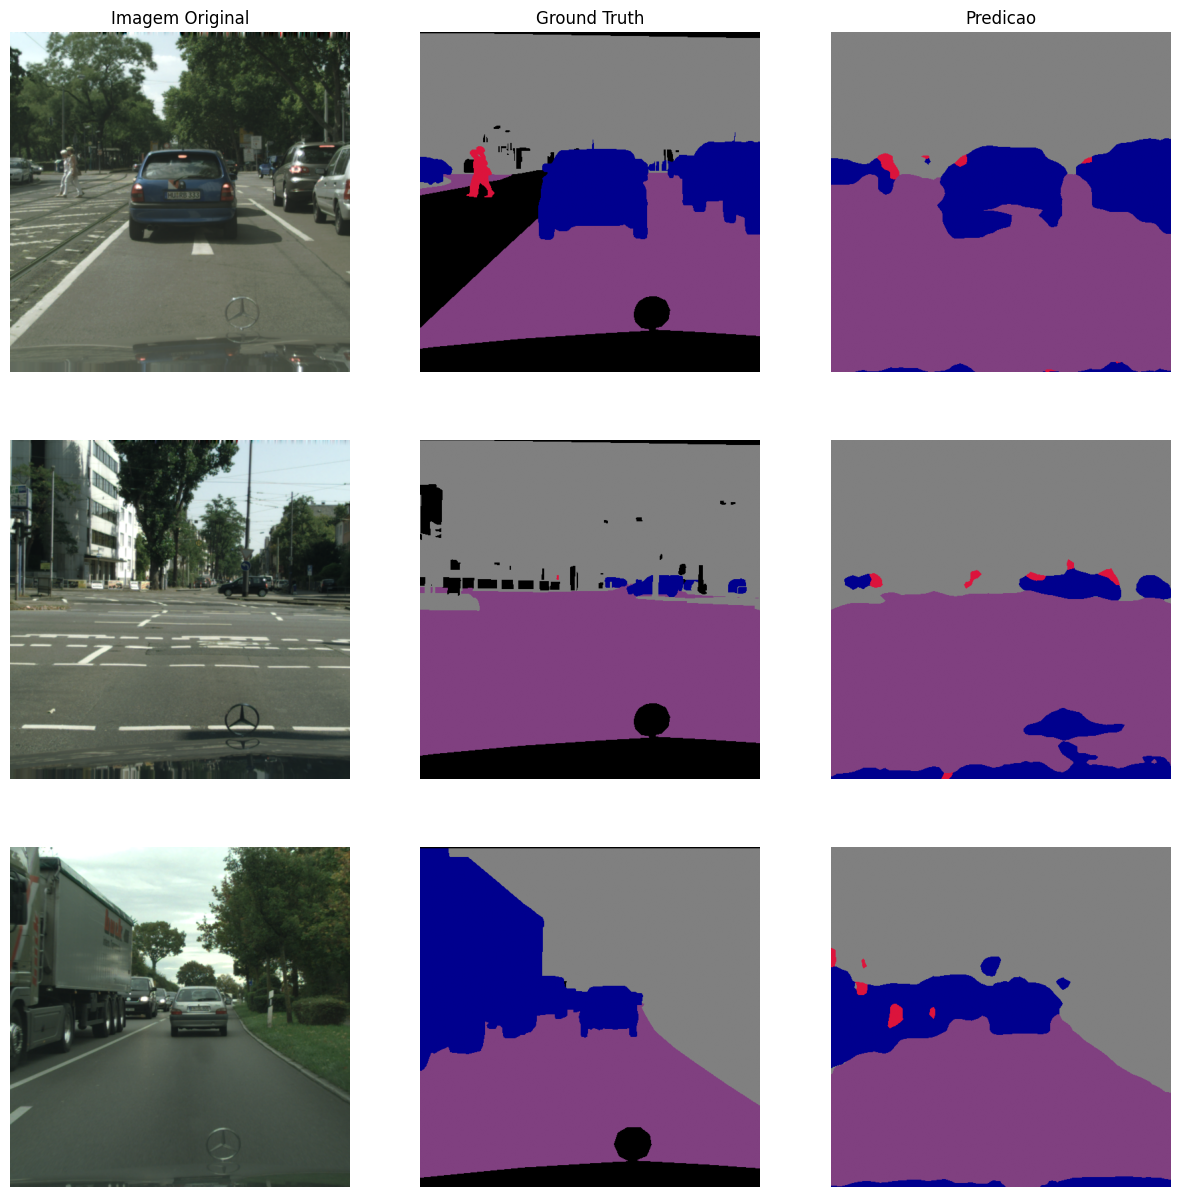

In [11]:
dataset_show(quant_val_dataset, n=3, predict_masks=True, model=quant_model, device=device, cmap=cmap)

## Salvando Modelo Quantizado Treinado para QONNX

In [5]:
saved_quant_model = qfscnn.QFastSCNN(num_classes=NUM_CLASSES, mode="finn") # Criando o modelo quantizado, com o modo "finn" para exportacao para ONNX e FINN. Que garante o preprocessamento do input dentro do modelo.
saved_quant_model = load_state_dict(saved_quant_model, path=f"./model_weights/quant_params/best_{BIT_WIDTH}_bit_quant_model.pth", strict=False) # strict=False visto que os parametros "mean" e "std" não estão presentes no estado salvo.
saved_quant_model = saved_quant_model.to(device)

# No instância do modelo quantizada para teste de sanidade, no modo qat, para garantir que o modelo foi salvo corretamente
check_quant_model = qfscnn.QFastSCNN(num_classes=NUM_CLASSES, mode="qat")
check_quant_model = load_state_dict(check_quant_model, path=f"./model_weights/quant_params/best_{BIT_WIDTH}_bit_quant_model.pth", strict=True)
check_quant_model = check_quant_model.to(device)

Carregando modelo best_8_bit_quant_model


/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/torch/_utils.py:101: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:36.)
  untyped_storage = torch.UntypedStorage(self.size(), device=device)


Carregando modelo best_8_bit_quant_model


In [14]:
# Testar Parametros
sanity_check = ev.EvalModel(model=check_quant_model, device=device)
sanity_metrics = sanity_check.eval(quant_val_dataloader, metrics, loss_fn)

100%|██████████| 42/42 [00:30<00:00,  1.37it/s]

Eval Results: Loss - 0.0925 | mIoU - 0.5838 | 


In [6]:
# EXPORTANDO O MODELO QUANTIZADO PARA ONNX

# Para executar essa celula, necessario estar com flag BREVITAS_JIT = 0. Verificar no Config.py

# O caminho do modelo que você exportou com sucesso
export_path = f"../onnx/quant_model_{BIT_WIDTH}_bits.onnx"
log_grafo = f"../onnx/grafo_completo_onnx_{BIT_WIDTH}_bits.txt"

# Colocar o modelo quantizado em modo de eval, para garantir que as camadas de quantização e de normalização estejam no modo correto durante a exportação para ONNX
saved_quant_model.eval()

# Gerar o QONNX com input quadrado (1:1) para evitar problemas de exportacao, visto que o modelo quantizado foi treinado com entradas quadradas.
dummy_input = torch.randn(1, 3, IM_HEIGHT, IM_HEIGHT).to(device)
print("Exportando o modelo quantizado para ONNX. Verifique os warnings gerados para identificar possiveis incompatibilidades ou problemas na exportacao.\n")
export_qonnx(saved_quant_model, dummy_input, export_path=export_path, opset_version=13, disable_warnings=False, verbose=False)
print(f"\nModelo quantizado exportado para ONNX com sucesso no caminho: {export_path}")

print("Lendo o ficheiro ONNX gerado e extraindo o log completo...")

try:
    # 1. Carrega o ficheiro binário que o C++ gerou
    onnx_model = onnx.load(export_path)
    
    # 2. Extrai o texto gigante (O mesmo que o verbose=True tenta imprimir)
    grafo_em_texto = onnx.printer.to_text(onnx_model)
    
    # 3. Salva no nosso ficheiro .txt
    with open(log_grafo, "w", encoding="utf-8") as f:
        f.write("=== LOG COMPLETO DA TOPOLOGIA DO MODELO ONNX ===\n\n")
        f.write(grafo_em_texto)
        
    print(f"O log da rede completa foi salvo em: {log_grafo}")

except Exception as e:
    print(f"Erro ao tentar ler o ficheiro ONNX: {e}")

Exportando o modelo quantizado para ONNX. Verifique os warnings gerados para identificar possiveis incompatibilidades ou problemas na exportacao.



/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/torch/_tensor.py:1645: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1939.)
  return super().rename(names)
/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/brevitas/export/onnx/manager.py:185: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exp


Modelo quantizado exportado para ONNX com sucesso no caminho: ../onnx/quant_model_8_bits.onnx
Lendo o ficheiro ONNX gerado e extraindo o log completo...
O log da rede completa foi salvo em: ../onnx/grafo_completo_onnx_8_bits.txt


In [3]:
export_path = f"../onnx/quant_model_{BIT_WIDTH}_bits.onnx"

In [4]:
# ABRIR MODELO NO NETRON

def find_free_port(start=8082, max_tries=200):
    for p in range(start, start + max_tries):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("0.0.0.0", p))
                return p
            except OSError:
                continue
    raise RuntimeError("No free port found")

port = find_free_port(8082)
if port != 8082:
    print(f"Port 8082 busy, using {port} instead")

try:
    show_netron_model(export_path, port=port)
except OSError as e:
    # fallback: try to find another free port and retry once
    port = find_free_port(port+1)
    print(f"Retrying on port {port}")
    show_netron_model(export_path, port=port)

Serving '../onnx/quant_model_8_bits.onnx' at http://localhost:8082


## Área de Testes (NÃO É NECESSÁRIO EXECUTAR)

In [ ]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
import torch.nn.functional as F
import brevitas.nn as qnn
from brevitas.quant.scaled_int import Int8WeightPerTensorFloat, Uint8ActPerTensorFloat, Int8ActPerTensorFloat, Int8BiasPerTensorFloatInternalScaling
from brevitas.quant_tensor import QuantTensor
from config import BIT_WIDTH

quant_in = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, bit_width=BIT_WIDTH, return_quant_tensor=True)

in1 = torch.randn(1, 1, 4, 4)
in2 = torch.randn(1, 1, 4, 4)

in1_quant = quant_in(in1)
in2_quant = quant_in(in2)

print(f"in1 scale factor: {in1_quant.scale}\n"
      f"in2 scale factor: {in2_quant.scale}")

upsampled = F.interpolate(in1_quant, scale_factor=2, mode='nearest')
print(upsampled.value.shape)
upsampled

in1 scale factor: 0.021325640380382538
in2 scale factor: 0.012175707146525383
torch.Size([1, 1, 8, 8])


/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/torch/_tensor.py:1645: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1939.)
  return super().rename(names)


IntQuantTensor(value=tensor([[[[-2.6231, -2.6231,  1.4075,  1.4075,  0.5758,  0.5758, -0.5545,
           -0.5545],
          [-2.6231, -2.6231,  1.4075,  1.4075,  0.5758,  0.5758, -0.5545,
           -0.5545],
          [-0.4905, -0.4905,  0.7251,  0.7251, -0.5758, -0.5758,  1.0663,
            1.0663],
          [-0.4905, -0.4905,  0.7251,  0.7251, -0.5758, -0.5758,  1.0663,
            1.0663],
          [ 0.6184,  0.6184,  0.9597,  0.9597,  1.3009,  1.3009, -0.1280,
           -0.1280],
          [ 0.6184,  0.6184,  0.9597,  0.9597,  1.3009,  1.3009, -0.1280,
           -0.1280],
          [ 0.1066,  0.1066,  0.0427,  0.0427,  2.7084,  2.7084, -1.4715,
           -1.4715],
          [ 0.1066,  0.1066,  0.0427,  0.0427,  2.7084,  2.7084, -1.4715,
           -1.4715]]]], grad_fn=<UpsampleNearest2DBackward0>), scale=tensor(0.0213, grad_fn=<DivBackward0>), zero_point=tensor(0.), bit_width=tensor(8.), signed_t=tensor(True), training_t=tensor(True))

In [4]:
upsample = qnn.QuantUpsample(scale_factor=2, mode='nearest', return_quant_tensor=True)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import brevitas.nn as qnn
from brevitas.quant.scaled_int import Int8WeightPerTensorFloat, Uint8ActPerTensorFloat, Int8ActPerTensorFloat, Int8BiasPerTensorFloatInternalScaling
from brevitas.quant_tensor import QuantTensor
from brevitas.inject.enum import *

BIT_WIDTH = 8
up_scale = (2, 4)
og_tensor = torch.randn(1, 1, 2, 2)
input_quant = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
og_tensor = input_quant(og_tensor)
print(og_tensor)
upsample = qnn.QuantConvTranspose2d(1, 1, up_scale, stride=up_scale, padding=0, groups=1,bias=False, weight_bit_width=BIT_WIDTH, weight_quant=Int8WeightPerTensorFloat, return_quant_tensor=True)
upsample.eval()

with torch.inference_mode():
    for param in upsample.parameters():
        param.requires_grad = False
    nn.init.constant_(upsample.weight.data, 1.0)
    output = upsample(og_tensor)
print(output)

print(f"Input shape: {og_tensor.shape}\n"
      f"Output shape: {output.shape}")

IntQuantTensor(value=tensor([[[[ 1.5711,  0.6309],
          [ 0.5938, -0.7917]]]], grad_fn=<MulBackward0>), scale=0.012370523065328598, zero_point=0.0, bit_width=8.0, signed_t=True, training_t=True)
IntQuantTensor(value=tensor([[[[ 1.5711,  1.5711,  1.5711,  1.5711,  0.6309,  0.6309,  0.6309,
            0.6309],
          [ 1.5711,  1.5711,  1.5711,  1.5711,  0.6309,  0.6309,  0.6309,
            0.6309],
          [ 0.5938,  0.5938,  0.5938,  0.5938, -0.7917, -0.7917, -0.7917,
           -0.7917],
          [ 0.5938,  0.5938,  0.5938,  0.5938, -0.7917, -0.7917, -0.7917,
           -0.7917]]]]), scale=tensor([[[[9.7406e-05]]]]), zero_point=tensor([0.]), bit_width=17.0, signed_t=True, training_t=True)
Input shape: torch.Size([1, 1, 2, 2])
Output shape: torch.Size([1, 1, 4, 8])


/home/jose-vitor/finn-repo/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/torch/_tensor.py:1645: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1939.)
  return super().rename(names)


In [15]:
torch.cuda.empty_cache()